<a href="https://colab.research.google.com/github/dharmaakula379-git/ML-LAB/blob/main/Ex2_postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Missing Values Before Preprocessing
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class        

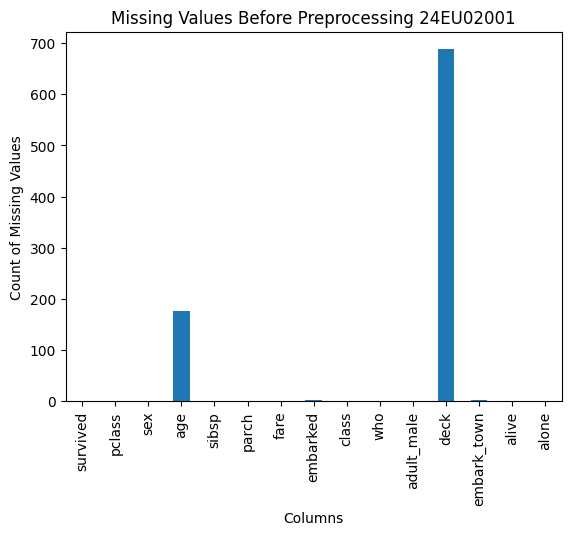


Missing Values After Preprocessing
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

Preprocessed Dataset
   survived  pclass  sex   age  sibsp  parch     fare  embarked  adult_male  \
0         0       3    1  22.0      1      0   7.2500         2           1   
1         1       1    0  38.0      1      0  71.2833         0           0   
2         1       3    0  26.0      0      0   7.9250         2           0   
3         1       1    0  35.0      1      0  53.1000         2           0   
4         0       3    1  35.0      0      0   8.0500         2           1   

   alone  
0      0  
1      0  
2      1  
3      0  
4      1  


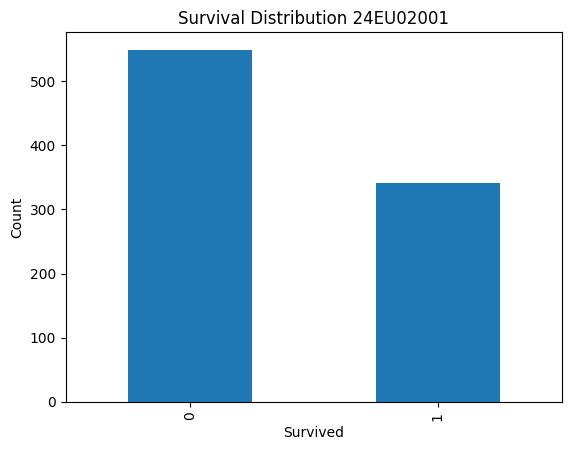

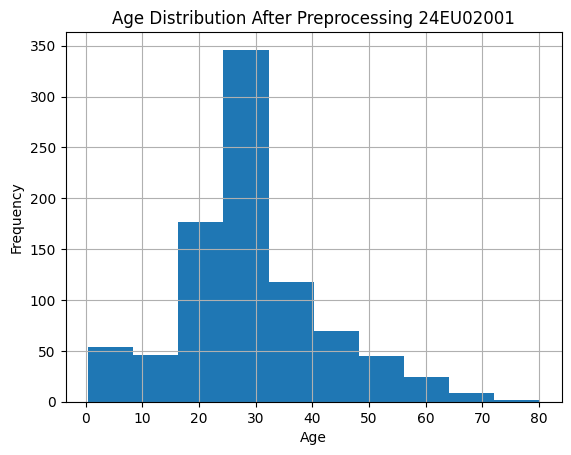

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 5 rows
print("Original Dataset")
print(df.head())

# Check missing values
print("\nMissing Values Before Preprocessing")
print(df.isnull().sum())

# Visualization of missing values
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values Before Preprocessing 24EU02001")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.show()

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop columns with many missing values
df.drop(['deck', 'embark_town', 'alive', 'class', 'who'], axis=1, inplace=True)

# Encode categorical columns
le = LabelEncoder()

categorical_columns = ['sex', 'adult_male', 'alone', 'embarked']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Check missing values after preprocessing
print("\nMissing Values After Preprocessing")
print(df.isnull().sum())

# Display preprocessed dataset
print("\nPreprocessed Dataset")
print(df.head())

# Visualization after preprocessing
df['survived'].value_counts().plot(kind='bar')
plt.title("Survival Distribution 24EU02001")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

df['age'].hist()
plt.title("Age Distribution After Preprocessing 24EU02001")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()